# Wavetable Synthesis

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from IPython.display import Audio
from scipy.io.wavfile import read

With wavetable synthesis, we pre-compute waveforms and store them in a buffer (or array) to be read over and over. By repeatedly reading one period of the waveform, we create a "continuous" wave. 

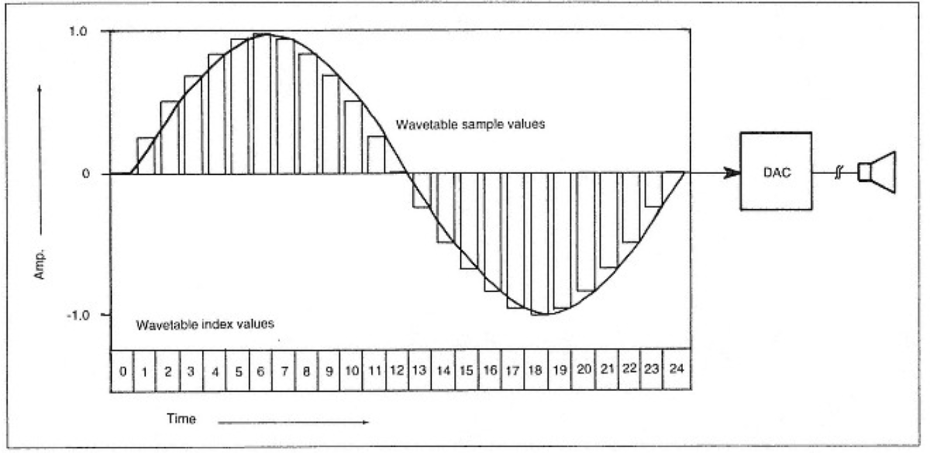

Let's create a sine wave without wavetable synthesis. 

We need to set the amount of time we need from the start with np.arange(). We'll start with 2 seconds

With that code, we had to calculate the cosine function 88200 times (fs * 2 seconds).

In [7]:
len(t)

88200

In [13]:
len(x)

88200

Now, let's build a wavetable.

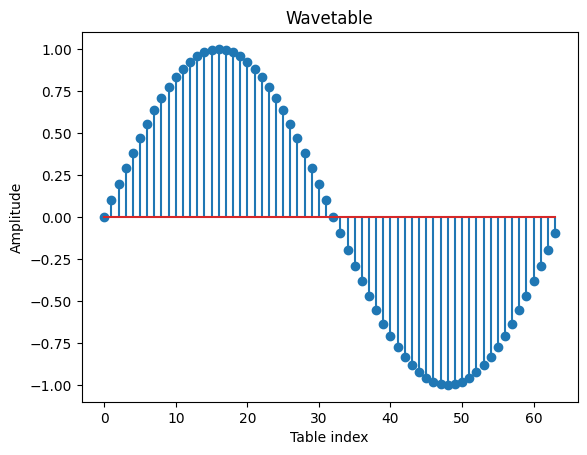

array([ 0.00000000e+00,  9.80171403e-02,  1.95090322e-01,  2.90284677e-01,
        3.82683432e-01,  4.71396737e-01,  5.55570233e-01,  6.34393284e-01,
        7.07106781e-01,  7.73010453e-01,  8.31469612e-01,  8.81921264e-01,
        9.23879533e-01,  9.56940336e-01,  9.80785280e-01,  9.95184727e-01,
        1.00000000e+00,  9.95184727e-01,  9.80785280e-01,  9.56940336e-01,
        9.23879533e-01,  8.81921264e-01,  8.31469612e-01,  7.73010453e-01,
        7.07106781e-01,  6.34393284e-01,  5.55570233e-01,  4.71396737e-01,
        3.82683432e-01,  2.90284677e-01,  1.95090322e-01,  9.80171403e-02,
        1.22464680e-16, -9.80171403e-02, -1.95090322e-01, -2.90284677e-01,
       -3.82683432e-01, -4.71396737e-01, -5.55570233e-01, -6.34393284e-01,
       -7.07106781e-01, -7.73010453e-01, -8.31469612e-01, -8.81921264e-01,
       -9.23879533e-01, -9.56940336e-01, -9.80785280e-01, -9.95184727e-01,
       -1.00000000e+00, -9.95184727e-01, -9.80785280e-01, -9.56940336e-01,
       -9.23879533e-01, -

Any value within our sinusoid can be read by indexing out the table.

0.0
0.8314696123025452
0.1950903220161286
-0.0980171403295605


How do we calculate the right index?

We need something like the phasor in Max to mark the beginning and end of our table.

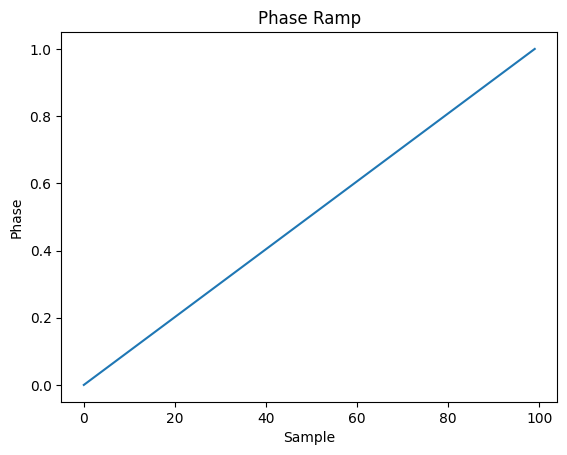

This gives us the 0-1 phasor like we've seen in Max, but we need to tie it to our desired frequency (and sampling rate). 

We can calculate the phase increment (or change in phase) by dividing our frequency by our sampling rate



0.009977324263038548


This tells us that across our sampling period (44100 samples per second) our oscillator should advance 0.00998th of a cycle. That gives us the 440 cycles per 441000 samples.

0
0.009977324263038548
0.019954648526077097
0.029931972789115645
0.039909297052154194
0.04988662131519274
0.059863945578231284
0.06984126984126983
0.07981859410430837
0.08979591836734692


After defining the phase increment, we can use that along with our known table size to index into our wavetable. We'll multiply our phase increment (phase difference) by the length of the table.


$$\frac{𝑘}{𝐿} = \frac{\theta}{2\pi}$$

k -> read location, sample index, “some sample k”

L -> length of table, number of samples

Our phase increment will equal:

$$ k = \frac{f*N}{f_s} $$

where N is the table length


In Python, we aren't going to synthesize our sine wave in real-time, but we can build a buffer using the same approach for wavetable playback.

Our pseudo-code:

Read_index = (prev_index + increment) % table_length

Output = amplitude_control * wavetable[read_index]



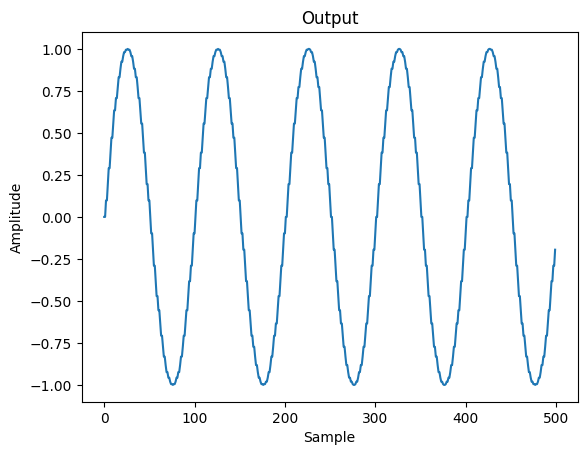

In [36]:
plt.plot(output)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Output")
plt.show()

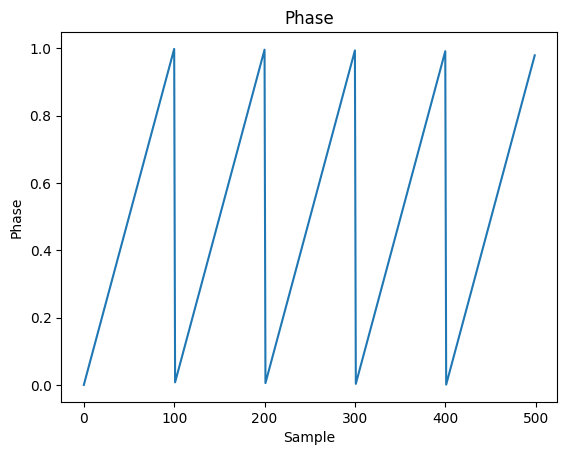

In [37]:
plt.plot(phase_values)
plt.xlabel("Sample")
plt.ylabel("Phase")
plt.title("Phase")
plt.show()

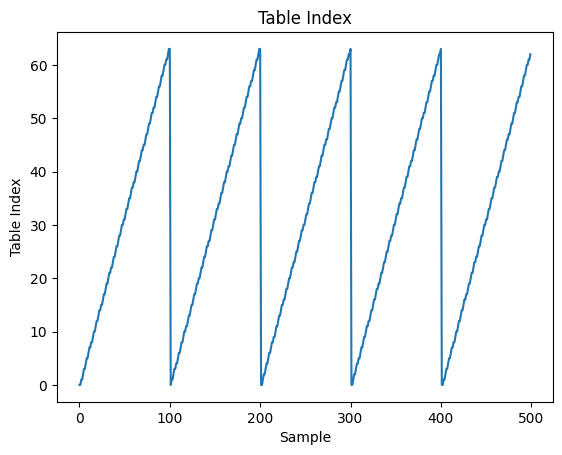

In [38]:
plt.plot(index_values)
plt.xlabel("Sample")
plt.ylabel("Table Index")
plt.title("Table Index")
plt.show()

We'll make the sine output longer so we can listen to the wavetable playback. 

Why does the sine wave not sound like a sine wave?

If we take a look again at our graph, our sine wave has discontinuities. This comes from us rounding our phase increment to integers to allow for indexing.

For example, we calculated our phase increment to be 0.00998 for 440 cycles per 441000 samples. When reading from our table all of our increment values will be decimals.

0
0.6385487528344671
1.2770975056689342
1.9156462585034013
2.5541950113378684
3.1927437641723353
3.831292517006802
4.469841269841269
5.108390022675736
5.746938775510203


In Python (or any programming language), we can't index a table with decimal values, so we previously truncated those values using int() casting. 

0
0
1
1
2
3
3
4
5
5


However, this causes jumps (discontinuities) in the wavetable playback as we heard with our sine wave.

There are better approaches using interpolation to make this playback smoother.

With linear interpolation, we compare the values in the table "before" and "after" the desired fractional value, then blend them based on the weight each side of the fraction holds.

$$y = y_1 + (x - x_1) \frac{y_2 - y_1}{x_2 - x_1}$$

$$sample = val_1 + (inc - ind_1) \frac{val_2 - val_1}{ind_2 - ind_1}$$

desired index: 40.867120181405895
fraction: 0.8671201814058946
index before: 40
index after: 41
table val before: -0.7071067811865475
table val after: -0.7730104533627367
interpolated sample: -0.7642531853592792


Let's re-calculate the wavetable playback using interpolation.

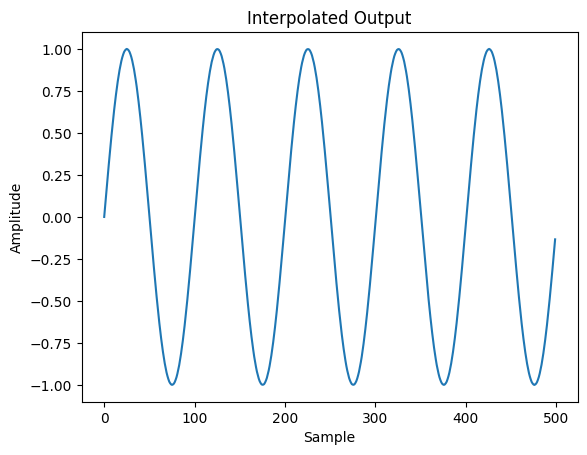

In [69]:
plt.plot(output_interp[:500])
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Interpolated Output")
plt.show()

We can look at the truncated and interpolated graphs together, and compare the output sound.

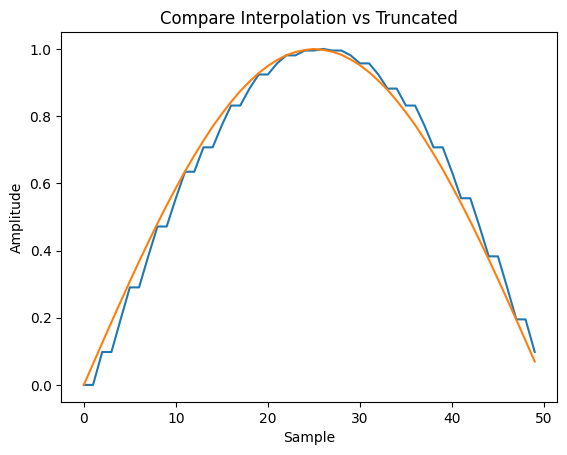

In [70]:
plt.plot(output[:50])
plt.plot(output_interp[:50])
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Compare Interpolation vs Truncated")
plt.show()

In [74]:
Audio(output, rate=fs)

In [72]:
Audio(output_interp, rate=fs)